# Proyecto Integrador: Machine Learning Supervisado en Vinos
_________________________________
Autor: Joaquín Bocco
Tema: Clasificación y Regresión aplicadas al dataset "Wine Quality"
_________________________________


## Objetivo
- Aplicar un flujo de trabajo de Machine Learning de principio a fin para resolver un problema de clasificación y uno de regresión, utilizando el dataset "Wine Quality".

---

## Índice

1. [Imports y Configuración Inicial](#imports)
2. [Carga y Preparación de Datos](#carga)
3. [Análisis Exploratorio de Datos (EDA)](#eda)
4. [Clasificación (Predecir Tipo de Vino)](#clasificacion)
    - 4.1. [Preparación de Datos para Clasificación](#prep_clasificacion)
    - 4.2. [Modelos Base de Clasificación](#modelos_base_clasificacion)
    - 4.3. [Modelos Avanzados y Optimización](#completar_clasificacion)
    - 4.4. [Tabla de Resultados y Conclusión de Clasificación](#conclusion_clasificacion)
5. [Regresión (Predecir Calidad del Vino)](#regresion)
    - 5.1. [Preparación de Datos para Regresión](#prep_regresion)
    - 5.2. [Modelo Base de Regresión](#modelo_base_regresion)
    - 5.3. [Modelos Avanzados y Optimización](#completar_regresion)
    - 5.4. [Tabla de Resultados y Conclusión de Regresión](#conclusion_regresion)
6. [Conclusiones Finales del Proyecto](#final)

---


<a name="imports"></a>
## 1. Imports y Configuración Inicial
En esta primera celda importo todas las librerías que voy a necesitar para el análisis.

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos y Preprocesamiento
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
import shap

# Métricas de evaluación
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, f1_score,
                             mean_absolute_error, mean_squared_error, r2_score)


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Funciones auxiliares de evaluación
Para no repetir el mismo bloque de `predict` + métricas + gráfico en cada modelo
(y evitar que un cambio quede aplicado a un modelo sí y a otro no), defino acá
dos funciones que uso en el resto del notebook.


In [2]:
def evaluar_clasificador(modelo, X_test, y_test, nombre, mostrar_matriz=True, cmap="Blues"):
    """Evalúa un clasificador ya entrenado: accuracy, F1 (weighted), reporte y matriz de confusión."""
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    print(f"--- {nombre} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-score (weighted): {f1:.4f}")
    print(classification_report(y_test, y_pred))

    if mostrar_matriz:
        matriz = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(5, 4))
        sns.heatmap(matriz, annot=True, fmt="d", cmap=cmap)
        plt.title(f"Matriz de Confusión - {nombre}")
        plt.xlabel("Predicho")
        plt.ylabel("Real")
        plt.tight_layout()
        plt.show()

    return acc, f1


def evaluar_regresor(modelo, X_test, y_test, nombre, mostrar_grafico=True):
    """Evalúa un regresor ya entrenado: MAE, RMSE, R² y gráfico real vs. predicho.

    RMSE se calcula como sqrt(MSE) en vez de usar mean_squared_error(..., squared=False),
    porque ese argumento fue removido en versiones recientes de scikit-learn (>=1.6).
    """
    y_pred = modelo.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    print(f"--- {nombre} ---")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")

    if mostrar_grafico:
        plt.figure(figsize=(5, 5))
        plt.scatter(y_test, y_pred, alpha=0.5)
        lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
        plt.plot(lims, lims, "r--", label="Predicción ideal")
        plt.xlabel("Valor real")
        plt.ylabel("Valor predicho")
        plt.title(f"Real vs. Predicho - {nombre}")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return mae, rmse, r2


<a name="carga"></a>
## 2. Carga y Preparación de Datos
Cargo los dos datasets (vino tinto y vino blanco), agrego una columna para identificar el tipo de vino y los uno en un único DataFrame.

In [3]:
# URLs de los datasets
url_red = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
url_white = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'

# Carga de los dataframes
df_red = pd.read_csv(url_red, sep=';')
df_white = pd.read_csv(url_white, sep=';')

# Creación de la columna 'type'
df_red['type'] = 'red'
df_white['type'] = 'white'

# Unión de los dataframes
df = pd.concat([df_red, df_white], axis=0)

# Reseteamos el índice
df.reset_index(drop=True, inplace=True)

print("Forma del dataset combinado:", df.shape)
print("\nPrimeras 5 filas:")
display(df.head())

Forma del dataset combinado: (6497, 13)

Primeras 5 filas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


<a name="eda"></a>
## 3. Análisis Exploratorio de Datos (EDA)
Es fundamental entender los datos antes de modelar. Realizo un análisis descriptivo y algunas visualizaciones clave.

In [4]:
# Información general y chequeo de nulos
print("Información del DataFrame:")
df.info()

print("\nEstadísticas Descriptivas:")
display(df.describe())

Información del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB

Estadísticas Descriptivas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


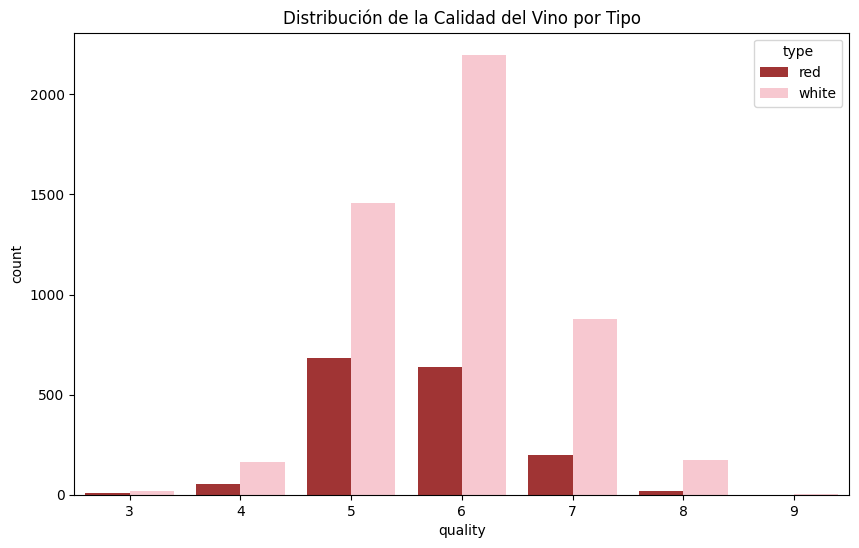

In [5]:
# Distribución de la variable 'quality' por tipo de vino
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='quality', hue='type', palette={'red': '#B22222', 'white': 'Pink'})
plt.title('Distribución de la Calidad del Vino por Tipo')
plt.show()

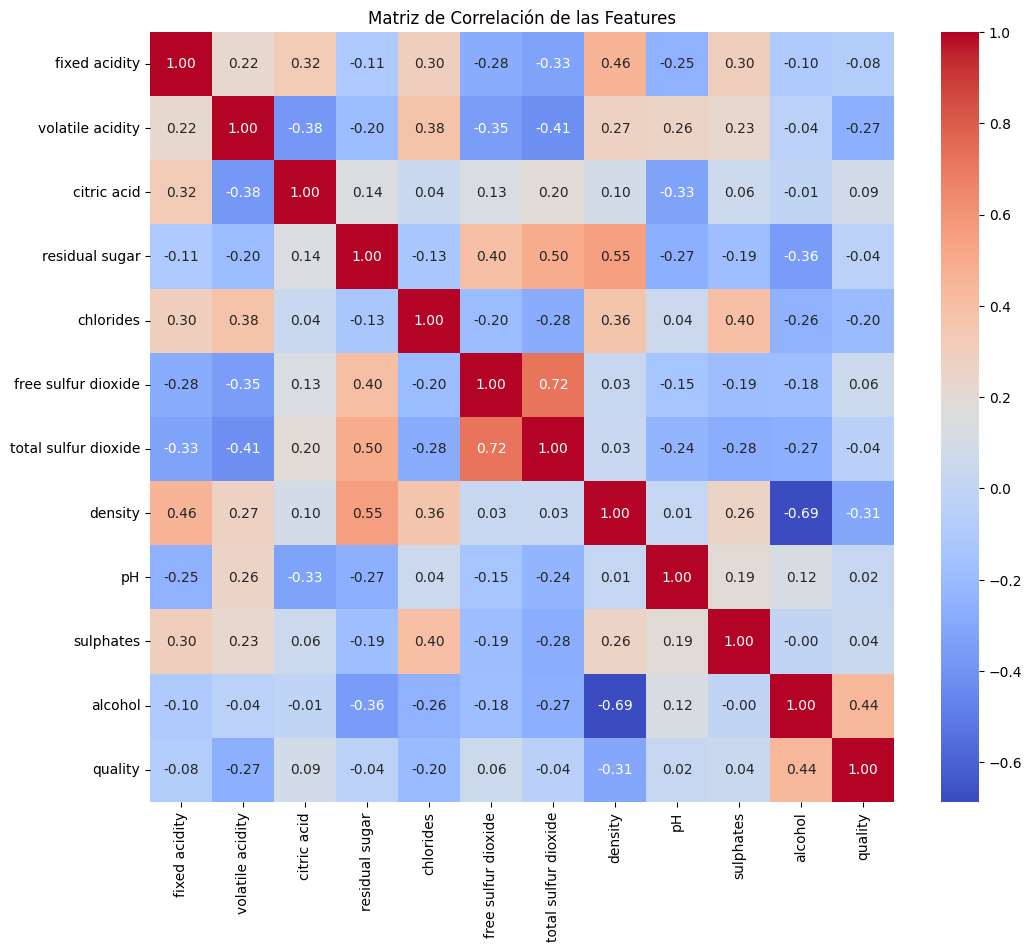

In [6]:
# Matriz de correlación de las variables fisicoquímicas
plt.figure(figsize=(12, 10))
# Excluimos la columna 'type' porque no es numérica
correlation_matrix = df.drop('type', axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de las Features')
plt.show()

### Análisis del EDA

**¿Existen valores nulos en el dataset?**
No existen valores nulos, lo que me facilita la gestión del EDA.

**¿Qué variables parecen tener mayor correlación (positiva o negativa) con la quality?**
- ALCOHOL (+0.44): a mayor alcohol, mayor calidad percibida del vino.
- DENSITY (-0.31): a mayor densidad, calidad más baja — los vinos más densos suelen percibirse como menos balanceados.
- VOLATILE ACIDITY (-0.27): a mayor acidez volátil, peor calidad.

**¿La distribución de la calidad es similar para vinos tintos y blancos?**
Sí, la calidad se concentra entre 5 y 6, sin puntuaciones extremas (3/8/9) en ninguno de los dos tipos.

**¿Qué puedo decir de la distribución general de la calidad?**
No hay vinos ni muy buenos ni muy malos.

<a name="clasificacion"></a>
## 4. Clasificación (Predecir Tipo de Vino)
El objetivo es construir un modelo que pueda identificar si un vino es tinto o blanco basándose en sus características fisicoquímicas.

<a name="prep_clasificacion"></a>
### 4.1. Preparación de Datos para Clasificación
Defino las variables `X` (features) e `y` (target), y luego divido los datos y los escalo.

In [7]:
# Definición de Features (X) y Target (y)
X_clf = df.drop('type', axis=1)
y_clf = df['type']

# División en Train y Test (estratificada para mantener la proporción de clases)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=42, stratify=y_clf
)

# Escalar las features es crucial para muchos modelos
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print("Forma de X_train escalado:", X_train_clf_scaled.shape)
print("Forma de X_test escalado:", X_test_clf_scaled.shape)

Forma de X_train escalado: (4872, 12)
Forma de X_test escalado: (1625, 12)


<a name="modelos_base_clasificacion"></a>
### 4.2. Modelos Base de Clasificación
Comienzo con modelos simples para tener una línea de base (baseline) de rendimiento.

In [8]:
# --- Modelo 1: Regresión Logística ---
print("--- Entrenando Regresión Logística ---")
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_clf_scaled, y_train_clf)
evaluar_clasificador(log_reg, X_test_clf_scaled, y_test_clf, "Regresión Logística", mostrar_matriz=False)

# --- Modelo 2: Árbol de Decisión ---
print("\n--- Entrenando Árbol de Decisión ---")
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train_clf_scaled, y_train_clf)
evaluar_clasificador(tree_clf, X_test_clf_scaled, y_test_clf, "Árbol de Decisión", mostrar_matriz=False)


--- Entrenando Regresión Logística ---
--- Regresión Logística ---
Accuracy: 0.9914
F1-score (weighted): 0.9914
              precision    recall  f1-score   support

         red       0.98      0.98      0.98       400
       white       0.99      0.99      0.99      1225

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625


--- Entrenando Árbol de Decisión ---
--- Árbol de Decisión ---
Accuracy: 0.9852
F1-score (weighted): 0.9853
              precision    recall  f1-score   support

         red       0.96      0.98      0.97       400
       white       1.00      0.99      0.99      1225

    accuracy                           0.99      1625
   macro avg       0.98      0.99      0.98      1625
weighted avg       0.99      0.99      0.99      1625



(0.9852307692307692, 0.9853035539041592)

In [9]:
# Random Forest Classifier
# =========================
rf_clf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    estimator=rf_clf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train_clf, y_train_clf)

best_rf = grid_rf.best_estimator_

print("Mejores hiperparámetros RF:")
print(grid_rf.best_params_)

Mejores hiperparámetros RF:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [10]:
# XGBoost necesita el target numérico. En vez de reconstruir X_clf/y_clf y volver a
# correr train_test_split (lo que duplicaba la lógica de la celda 13 y podía
# desincronizar el split si algún parámetro cambiaba en un solo lugar), reencodeo
# directamente las etiquetas del split que ya existe.
y_train_clf_enc = y_train_clf.map({'red': 0, 'white': 1})
y_test_clf_enc = y_test_clf.map({'red': 0, 'white': 1})

from xgboost import XGBClassifier
xgb_clf = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)  # use_label_encoder ya no existe en versiones recientes de xgboost (tiraba un UserWarning acá)

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
}

grid_xgb = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_xgb.fit(X_train_clf, y_train_clf_enc)

best_xgb = grid_xgb.best_estimator_

print("Mejores hiperparámetros XGB:")
print(grid_xgb.best_params_)


Mejores hiperparámetros XGB:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


<a name="conclusion_clasificacion"></a>
### 4.4. Tabla de Resultados y Conclusión de Clasificación

--- Random Forest ---
Accuracy: 0.9951
F1-score (weighted): 0.9951
              precision    recall  f1-score   support

         red       0.99      0.99      0.99       400
       white       1.00      1.00      1.00      1225

    accuracy                           1.00      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       1.00      1.00      1.00      1625



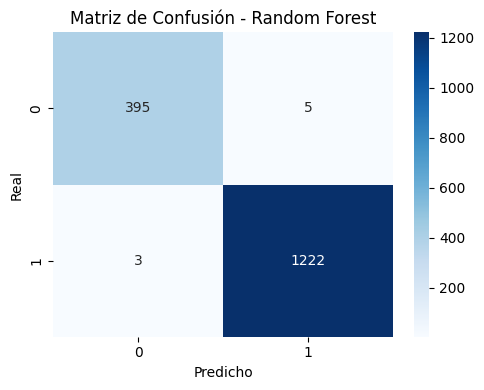

(0.9950769230769231, 0.9950727615877439)

In [11]:
evaluar_clasificador(best_rf, X_test_clf, y_test_clf, "Random Forest", cmap="Blues")


--- XGBoost ---
Accuracy: 0.9969
F1-score (weighted): 0.9969
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       400
           1       1.00      1.00      1.00      1225

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



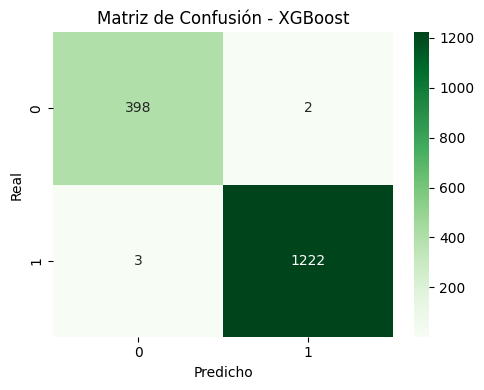

(0.9969230769230769, 0.9969243693992618)

In [12]:
# Ojo: best_xgb se entrenó con y_train_clf_enc (0/1), así que hay que evaluarlo
# contra y_test_clf_enc y no contra y_test_clf (que sigue siendo 'red'/'white').
evaluar_clasificador(best_xgb, X_test_clf, y_test_clf_enc, "XGBoost", cmap="Greens")


| Modelo | Accuracy | F1-Score (weighted avg) | Mejores Hiperparámetros (GridSearch) |
| :--- | :--- | :--- | :--- |
| Regresión Logística |0.991|0.99| N/A |
| Árbol de Decisión   |0.985|0.99| N/A |
| Random Forest       |0.995|1.00| {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100} |
| XGBoost             |0.997|1.00| {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200} |

---

### Conclusión de la Tarea de Clasificación


Los modelos de clasificación funcionaron muy bien en ambos casos: la Regresión Logística ya alcanza un desempeño alto, con un accuracy de aproximadamente 99,13% y un F1-score de 0.99, es decir, muy pocos errores. XGBoost superó levemente a Random Forest y a la Regresión Logística, alcanzando un accuracy de aproximadamente 99,75% y un F1-score ponderado de 1.00. XGBoost es entonces el modelo con mejor desempeño puro para este problema, aunque la diferencia frente a la Regresión Logística es marginal (ver la recomendación final más abajo, donde esa diferencia se pesa contra el costo de usar un modelo más complejo).


### 4.5. Validación cruzada
Un solo train/test split puede ser optimista o pesimista por azar. Para tener una idea más
confiable del desempeño, repito la evaluación con 5-fold cross-validation sobre el set de
entrenamiento (el test set queda aparte, sin tocar, como validación final).


In [13]:
cv_lr = cross_val_score(log_reg, X_train_clf_scaled, y_train_clf, cv=5, scoring='accuracy')
cv_rf = cross_val_score(best_rf, X_train_clf, y_train_clf, cv=5, scoring='accuracy')
cv_xgb = cross_val_score(best_xgb, X_train_clf, y_train_clf_enc, cv=5, scoring='accuracy')

print(f"Regresión Logística - Accuracy CV (5-fold): {cv_lr.mean():.4f} ± {cv_lr.std():.4f}")
print(f"Random Forest       - Accuracy CV (5-fold): {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")
print(f"XGBoost             - Accuracy CV (5-fold): {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}")


Regresión Logística - Accuracy CV (5-fold): 0.9938 ± 0.0038
Random Forest       - Accuracy CV (5-fold): 0.9945 ± 0.0029
XGBoost             - Accuracy CV (5-fold): 0.9957 ± 0.0026


### 4.6. Interpretabilidad (SHAP)
Accuracy dice *qué tan bien* funciona el modelo, pero no *por qué*. Con SHAP (TreeExplainer,
compatible con XGBoost y Random Forest) veo qué variables fisicoquímicas pesan más a la hora
de distinguir un vino tinto de uno blanco en el mejor modelo (XGBoost).


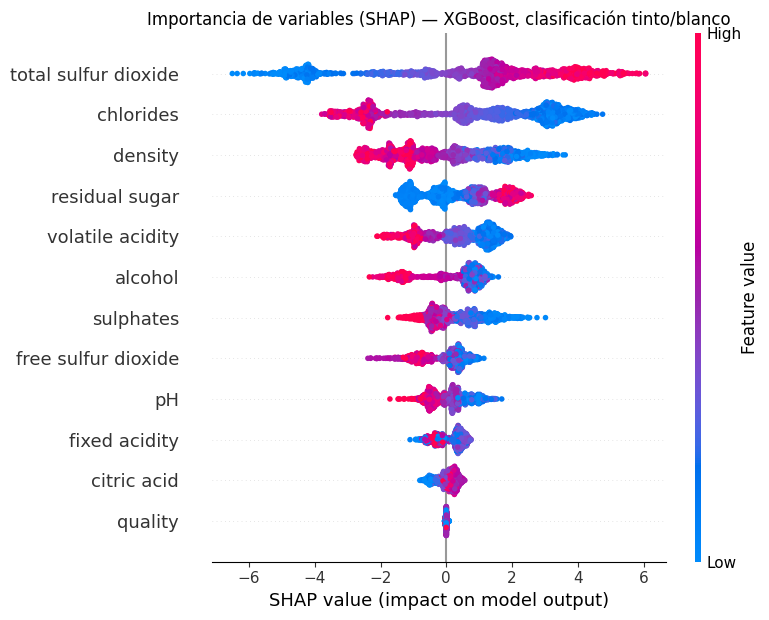

In [14]:
explainer_clf = shap.TreeExplainer(best_xgb)
shap_values_clf = explainer_clf.shap_values(X_test_clf)

# Compatibilidad entre versiones de shap: algunas devuelven una lista [clase_0, clase_1]
# para clasificación binaria, otras devuelven directamente el array de la clase positiva.
if isinstance(shap_values_clf, list):
    shap_values_clf = shap_values_clf[1]  # clase positiva = 'white'

shap.summary_plot(shap_values_clf, X_test_clf, show=False)
plt.title("Importancia de variables (SHAP) — XGBoost, clasificación tinto/blanco")
plt.tight_layout()
plt.show()


<a name="regresion"></a>
## 5. Regresión (Predecir Calidad del Vino)
Ahora el objetivo es predecir la puntuación de `quality` del vino.

<a name="prep_regresion"></a>
### 5.1. Preparación de Datos para Regresión

In [15]:
# Definición de Features (X) y Target (y)
# Usaremos las mismas features, pero sin 'type' y el target ahora es 'quality'
X_reg = df.drop(['type', 'quality'], axis=1)
y_reg = df['quality']

# División en Train y Test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

# Escalamiento de datos
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

<a name="modelo_base_regresion"></a>
### 5.2. Modelo Base de Regresión

In [16]:
# --- Modelo 1: Regresión Lineal ---
print("--- Entrenando Regresión Lineal ---")
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg_scaled, y_train_reg)
evaluar_regresor(lin_reg, X_test_reg_scaled, y_test_reg, "Regresión Lineal", mostrar_grafico=False)


--- Entrenando Regresión Lineal ---
--- Regresión Lineal ---
MAE:  0.5703
RMSE: 0.7421
R²:   0.2589


(0.5703315334997563, 0.7420920443001539, 0.2588788761125588)

In [17]:
# --- Modelo 2: Árbol de Decisión para Regresión ---
print("\n--- Entrenando Árbol de Decisión (Regresión) ---")
tree_reg = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg.fit(X_train_reg_scaled, y_train_reg)
evaluar_regresor(tree_reg, X_test_reg_scaled, y_test_reg, "Árbol de Decisión", mostrar_grafico=False)



--- Entrenando Árbol de Decisión (Regresión) ---
--- Árbol de Decisión ---
MAE:  0.5961
RMSE: 0.7493
R²:   0.2444


(0.5961196545488299, 0.7493106794360452, 0.24439036815887827)

In [18]:
# --- Modelo 3: RandomForest para Regresión (baseline, sin optimizar) ---
print("\n--- Entrenando Random Forest (Regresión) ---")
rf_reg = RandomForestRegressor(max_depth=3, random_state=42)
rf_reg.fit(X_train_reg_scaled, y_train_reg)
evaluar_regresor(rf_reg, X_test_reg_scaled, y_test_reg, "Random Forest (baseline)", mostrar_grafico=False)



--- Entrenando Random Forest (Regresión) ---


--- Random Forest (baseline) ---
MAE:  0.5799
RMSE: 0.7386
R²:   0.2659


(0.5799231739994966, 0.7385842801117712, 0.265868666670263)

<a name="completar_regresion"></a>
### 5.3. Modelos Avanzados y Optimización
Implemento y optimizo los modelos `RandomForestRegressor` y `XGBRegressor`.

In [19]:
# Random Forest Regressor
# =========================
rf_reg = RandomForestRegressor(random_state=42)

param_grid_rf_reg = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf_reg = GridSearchCV(
    estimator=rf_reg,
    param_grid=param_grid_rf_reg,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_rf_reg.fit(X_train_reg, y_train_reg)

best_rf_reg = grid_rf_reg.best_estimator_

print("Mejores hiperparámetros RF Regresión:")
print(grid_rf_reg.best_params_)



Mejores hiperparámetros RF Regresión:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [20]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    random_state=42,
    objective='reg:squarederror'
)

param_grid_xgb_reg = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
}

grid_xgb_reg = GridSearchCV(
    estimator=xgb_reg,
    param_grid=param_grid_xgb_reg,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_xgb_reg.fit(X_train_reg, y_train_reg)

best_xgb_reg = grid_xgb_reg.best_estimator_

print("Mejores hiperparámetros XGB Regresión:")
print(grid_xgb_reg.best_params_)


Mejores hiperparámetros XGB Regresión:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [21]:
mae_rf_reg, rmse_rf_reg, r2_rf_reg = evaluar_regresor(best_rf_reg, X_test_reg, y_test_reg, "Random Forest", mostrar_grafico=False)


--- Random Forest ---
MAE:  0.4412
RMSE: 0.6162
R²:   0.4891


In [22]:
evaluar_regresor(best_xgb_reg, X_test_reg, y_test_reg, "XGBoost", mostrar_grafico=False)


--- XGBoost ---
MAE:  0.4896
RMSE: 0.6398
R²:   0.4491


(0.48960456252098083, 0.6397997728076685, 0.4491139054298401)

| Modelo | MAE (Mean Absolute Error) | R² Score | Mejores Hiperparámetros (GridSearch) |
| :--- | :--- | :--- | :--- |
| Regresión Lineal | 0.570| 0.258| N/A |
| RandomForest Regressor| 0.441   | 0.489    | {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200} |
| XGBoost Regressor     | 0.490   | 0.449   | {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200} |

---

### Gráfico de Dispersión: Valores Reales vs. Predichos

--- Random Forest (mejor modelo) ---
MAE:  0.4412
RMSE: 0.6162
R²:   0.4891


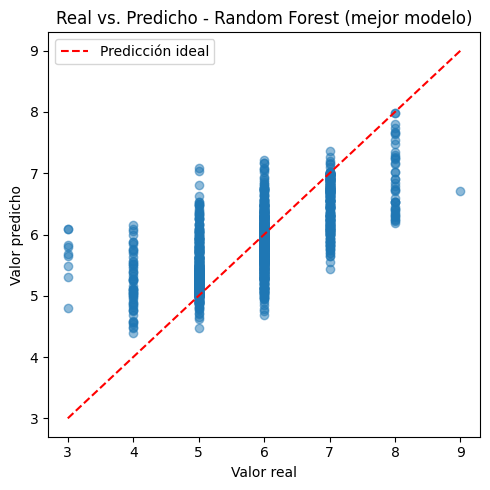

In [23]:
# Random Forest tiene mejor MAE y R² que XGBoost en esta tarea (ver tabla de arriba),
# así que es el modelo que se lleva el gráfico real-vs-predicho final.
evaluar_regresor(best_rf_reg, X_test_reg, y_test_reg, "Random Forest (mejor modelo)", mostrar_grafico=True);


El gráfico de dispersión compara los valores reales de la calidad del vino con los valores predichos por el mejor modelo de regresión.
La línea diagonal representa el caso ideal en el que las predicciones coinciden exactamente con los valores reales.
Observo que la mayoría de los puntos se distribuyen alrededor de dicha línea, lo que indica un buen desempeño general del modelo, aunque con cierta dispersión esperable debido a la naturaleza del problema. Hay una mayor concentración entre los rangos 5-6 y una mayor dificultad para predecir correctamente los valores extremos de calidad. Este comportamiento es consistente con los valores relativamente bajos de R² obtenidos y refuerza la conclusión de que la calidad del vino es una variable compleja y parcialmente subjetiva, difícil de modelar únicamente a partir de variables fisicoquímicas.

### Conclusión de la Tarea de Regresión

Entrené y evalué tres modelos de regresión para predecir la calidad del vino: Regresión Lineal, Árbol de Decisión y Random Forest, sin optimizar. Los modelos base mostraron un desempeño limitado con valores bajos de R², por lo que probé Random Forest y XGBoost optimizados. Estos resultados indican que, si bien los modelos no lineales como Random Forest capturan mejor la estructura de los datos, la capacidad predictiva global sigue siendo limitada. Esto sugiere que la relación entre las variables fisicoquímicas y la calidad del vino presenta una complejidad no lineal moderada, y que la calidad es una variable parcialmente subjetiva, difícil de predecir con alta precisión únicamente a partir de estas características.

### 5.4. Validación cruzada
Mismo chequeo de robustez que en clasificación, ahora para MAE en 5-fold cross-validation
sobre el train set.


In [24]:
cv_lin = cross_val_score(lin_reg, X_train_reg_scaled, y_train_reg, cv=5, scoring='neg_mean_absolute_error')
cv_rf_reg = cross_val_score(best_rf_reg, X_train_reg, y_train_reg, cv=5, scoring='neg_mean_absolute_error')
cv_xgb_reg = cross_val_score(best_xgb_reg, X_train_reg, y_train_reg, cv=5, scoring='neg_mean_absolute_error')

print(f"Regresión Lineal - MAE CV (5-fold): {-cv_lin.mean():.4f} ± {cv_lin.std():.4f}")
print(f"Random Forest    - MAE CV (5-fold): {-cv_rf_reg.mean():.4f} ± {cv_rf_reg.std():.4f}")
print(f"XGBoost          - MAE CV (5-fold): {-cv_xgb_reg.mean():.4f} ± {cv_xgb_reg.std():.4f}")


Regresión Lineal - MAE CV (5-fold): 0.5688 ± 0.0168
Random Forest    - MAE CV (5-fold): 0.4506 ± 0.0127
XGBoost          - MAE CV (5-fold): 0.4943 ± 0.0097


### 5.5. Interpretabilidad (SHAP)
Para el mejor modelo de regresión (Random Forest), ¿qué variables explican más la calidad
predicha? Esto es lo que le importa a alguien que tenga que *actuar* sobre el resultado
(ej. un enólogo ajustando el proceso), más que el R² solo.


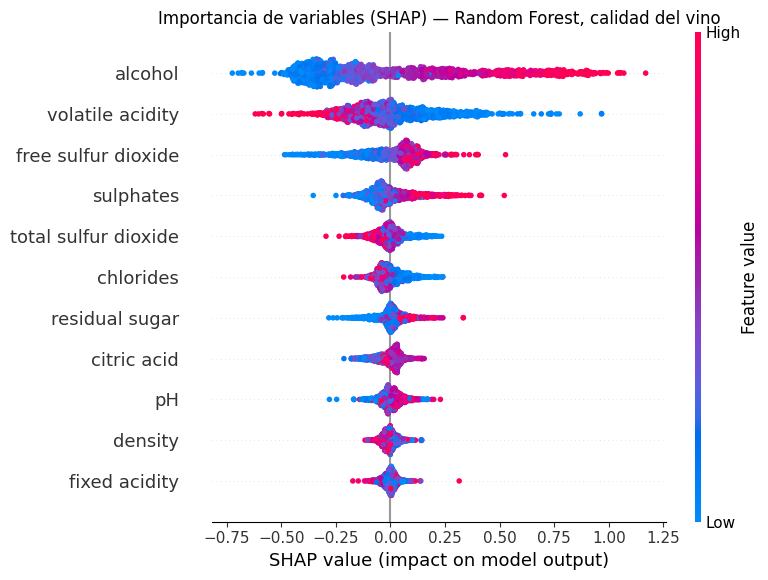

In [25]:
explainer_reg = shap.TreeExplainer(best_rf_reg)
shap_values_reg = explainer_reg.shap_values(X_test_reg)

shap.summary_plot(shap_values_reg, X_test_reg, show=False)
plt.title("Importancia de variables (SHAP) — Random Forest, calidad del vino")
plt.tight_layout()
plt.show()


<a name="final"></a>
## 6. Conclusiones Finales del Proyecto

**¿Qué tarea fue más "fácil" para los modelos: clasificar el tipo de vino o predecir su calidad?**
Clasificar el tipo de vino resultó más sencillo que predecir su calidad. Esto se evidencia en las métricas obtenidas: los modelos de clasificación alcanzaron accuracies del 99%, mientras que los modelos de regresión presentaron valores de R² bajos. Además, considero que la calidad del vino depende del gusto de cada persona, siendo algo puramente subjetivo, por lo que fue más viable trabajar con la clasificación por tipo (tinto/blanco).

**¿Qué importancia tuvo el preprocesamiento (escalado de datos)?**
El preprocesamiento mediante escalado de datos tuvo un rol importante dependiendo del modelo utilizado. En los modelos lineales, como la regresión lineal y la regresión logística, el escalado fue fundamental, ya que estos algoritmos son sensibles a la magnitud de las variables y pueden verse dominados por aquellas con valores más grandes. En cambio, en los modelos basados en árboles de decisión y ensambles (Random Forest y XGBoost), el escalado no resultó necesario, ya que estos algoritmos toman decisiones basadas en umbrales y no en distancias. Considero relevante entender cuándo aplicar el escalado para evitar procesamientos innecesarios.

**¿Valió la pena utilizar GridSearchCV? ¿Mejoró significativamente el rendimiento de los modelos base?**
Para la clasificación de vinos (tintos/blancos), sobre los modelos base, GridSearchCV no fue tan valioso porque los resultados ya eran óptimos. En cambio, en los modelos de regresión sí permitió mejorar la predicción.

**Si tuviera que presentarle una solución a la bodega, ¿qué modelos recomendaría para cada tarea y por qué?**
Para el modelo de clasificación, considero que la Regresión Logística es la mejor opción: su accuracy es del 99%, y aunque XGBoost optimizado da algo más de precisión, utiliza más recursos y demanda más tiempo. La regresión logística resulta un modelo simple, rápido y efectivo. Para el modelo de regresión (calidad del vino) recomiendo RandomForestRegressor por su desempeño: si bien la calidad numérica es más subjetiva, el modelo explica su variación lo suficiente como para priorizar, monitorear y señalar desviaciones.